
**LAB EXPERIMENT 10**\
**Recommendation Systems using Matrix Factorization
(SVD & NMF)**

NAME: Priya Dharshini R\
ROLL NO.: 24BAD092

**SCENARIO 1 – MATRIX FACTORIZATION USING SVD**

**Problem Statement**\
Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.

**Dataset (Kaggle – Public)** \
MovieLens Dataset\
Dataset Link:\
 https://www.kaggle.com/datasets/grouplens/movielens-100k

**Target Variable:** \
Predicted ratings for unseen movies\
**Input Feature:**  \
•	User ID \
•	Movie ID \
•	Ratings

**IN-LAB TASKS**

1.	Import required Python libraries (NumPy, Pandas, Scikit-learn, Surprise, etc.)

2.	Load the MovieLens dataset

3.	Perform data preprocessing
4.	Create User-Item Interaction Matrix
5.	Normalize the matrix (optional – mean centering)
6.	Apply SVD decomposition
7.	Reduce dimensions (select k latent factors)
8.	Reconstruct the matrix
9.	Predict missing ratings
10.	Generate Top-N recommendations

**Evaluation Metrics**\
•	RMSE (Root Mean Square Error) \
•	MAE (Mean Absolute Error)

**Analysis Tasks**\
•	Analyze effect of number of latent factors (k) \
•	Compare predicted vs actual ratings \
•	Observe how dimensionality reduction improves performance \
•	Study overfitting vs underfitting

**Visualization**\
•	Heatmap of original vs reconstructed matrix \
•	Error vs number of latent factors \
•	Top recommended movies




Name: Priya Dharshini R
Roll No.: 24BAD092
Scenario 1 – Matrix Factorization using SVD

Dataset Loaded Successfully!

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

User-Item Matrix Shape: (610, 9724)

Top 5 Recommendations for User 1:
     movieId                                      title
615      858                      Godfather, The (1972)
259      318           Shawshank Redemption, The (1994)
28        32  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
445      541                        Blade Runner (1982)
571      778                       Trainspotting (1996)

Evaluation Results (last k value):
RMSE: 0.5281689324546276
MAE: 0.3168499664413249


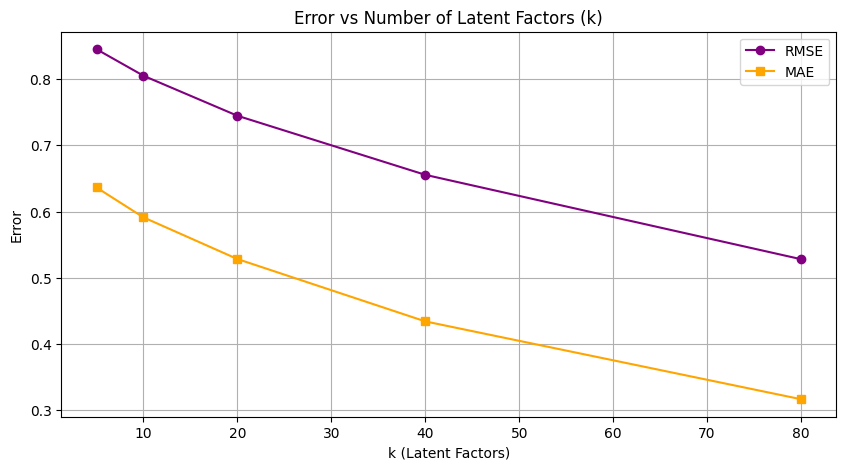

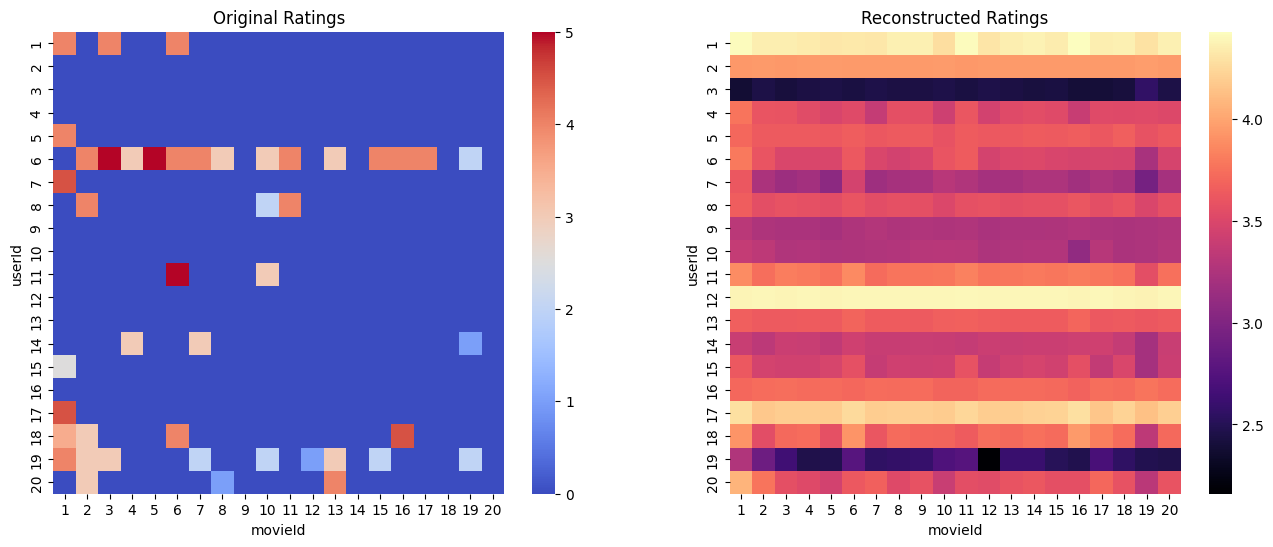

In [4]:
print("Name: Priya Dharshini R")
print("Roll No.: 24BAD092")
print("Scenario 1 – Matrix Factorization using SVD\n")

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error

# LOAD DATASET (CORRECT FILES)
df = pd.read_csv(r"/content/sample_data/ratings.csv")
movies_df = pd.read_csv(r"/content/sample_data/movies.csv")

print("Dataset Loaded Successfully!\n")
print(df.head())

# CREATE USER-ITEM MATRIX
user_movie_matrix = df.pivot(index='userId', columns='movieId', values='rating')
print("\nUser-Item Matrix Shape:", user_movie_matrix.shape)

# NORMALIZATION (MEAN CENTERING)
user_ratings_mean = np.nanmean(user_movie_matrix.values, axis=1)
R_demeaned = user_movie_matrix.values - user_ratings_mean.reshape(-1, 1)
R_demeaned = np.nan_to_num(R_demeaned)

# APPLY SVD
k_factors = 20
U, sigma, Vt = svds(R_demeaned, k=k_factors)
sigma = np.diag(sigma)

# RECONSTRUCT MATRIX
predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

preds_df = pd.DataFrame(predicted_ratings,
                        columns=user_movie_matrix.columns,
                        index=user_movie_matrix.index)

# RECOMMENDATION FUNCTION
def recommend_movies(predictions_df, userID, original_ratings_df, movies_df, num_recommendations=5):

    sorted_user_predictions = predictions_df.loc[userID].sort_values(ascending=False)

    user_data = original_ratings_df[original_ratings_df.userId == userID]

    recommendations = (movies_df[~movies_df['movieId'].isin(user_data['movieId'])]
                       .merge(pd.DataFrame(sorted_user_predictions).reset_index(),
                              how='left', on='movieId'))

    recommendations = recommendations.rename(columns={userID: 'PredictedRating'})
    recommendations = recommendations.sort_values('PredictedRating', ascending=False)

    return recommendations[['movieId', 'title']].head(num_recommendations)

# GENERATE RECOMMENDATIONS
user_id = 1
recommendations = recommend_movies(preds_df, user_id, df, movies_df, 5)

print(f"\nTop 5 Recommendations for User {user_id}:")
print(recommendations)

# EVALUATION METRICS
def calculate_errors(actual_matrix, predicted_matrix):
    mask = ~np.isnan(actual_matrix)
    actual = actual_matrix[mask]
    predicted = predicted_matrix[mask]

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    return rmse, mae

# ANALYZE DIFFERENT k VALUES
k_values = [5, 10, 20, 40, 80]
rmse_list = []
mae_list = []

for k in k_values:
    U_k, sigma_k, Vt_k = svds(R_demeaned, k=k)
    sigma_k = np.diag(sigma_k)

    pred_k = np.dot(np.dot(U_k, sigma_k), Vt_k) + user_ratings_mean.reshape(-1, 1)

    rmse, mae = calculate_errors(user_movie_matrix.values, pred_k)
    rmse_list.append(rmse)
    mae_list.append(mae)

print("\nEvaluation Results (last k value):")
print("RMSE:", rmse_list[-1])
print("MAE:", mae_list[-1])

# GRAPH (COLOR CUSTOMIZED)
plt.figure(figsize=(10,5))
plt.plot(k_values, rmse_list, marker='o', color='purple', label='RMSE')
plt.plot(k_values, mae_list, marker='s', color='orange', label='MAE')
plt.title('Error vs Number of Latent Factors (k)')
plt.xlabel('k (Latent Factors)')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

# HEATMAP VISUALIZATION
subset_actual = user_movie_matrix.iloc[:20, :20].fillna(0)
subset_pred = preds_df.iloc[:20, :20]

fig, ax = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(subset_actual, cmap='coolwarm', ax=ax[0])
ax[0].set_title('Original Ratings')

sns.heatmap(subset_pred, cmap='magma', ax=ax[1])
ax[1].set_title('Reconstructed Ratings')

plt.show()

**SCENARIO 2 – MATRIX FACTORIZATION USING NMF**

**Problem Statement**\
Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.

**Dataset**\
Same MovieLens Dataset (or any rating dataset)

**Target Variable:**\
 Predicted ratings / Recommendations\
**Input Features** \
•	User ID \
•	Movie ID \
•	Ratings

**IN-LAB TASKS**\
1.	Load dataset \
2.	Create User-Item matrix \
3.	Handle missing values (fill with 0 or mean) \
4.	Apply NMF model 5. Factorize into: \
a.	User-feature matrix \
b.	Item-feature matrix \
6.	Reconstruct the rating matrix\
7.	Predict missing values \
8.	Generate Top-N recommendations

**Evaluation Metrics**\
•	RMSE\
•	Precision@K\
•	Recall@K

**Analysis Tasks**\
•	Compare SVD vs NMF performance\
•	Observe interpretability of NMF factors\
•	Analyze sparsity handling\
•	Compare recommendation diversity

**Visualization**\
•	Latent feature visualization\
•	Reconstruction comparison\
•	Recommendation ranking chart


Name: Priya Dharshini R
Roll No.: 24BAD092
Scenario 2 – Matrix Factorization using NMF

Total ratings: 100836
User-Item Matrix Shape: (610, 9724)
Shape of W (User-Features): (610, 20)
Shape of H (Item-Features): (20, 9724)

Top 5 NMF Recommendations for User 1:
                                       title  Predicted_Rating
507        Terminator 2: Judgment Day (1991)          4.459315
793                          Die Hard (1988)          4.413284
902                            Aliens (1986)          3.321672
1057  Star Trek II: The Wrath of Khan (1982)          3.229055
2078                 Sixth Sense, The (1999)          3.200490

NMF RMSE: 2.4589
Precision@10: 0.5514
Recall@10: 0.1175


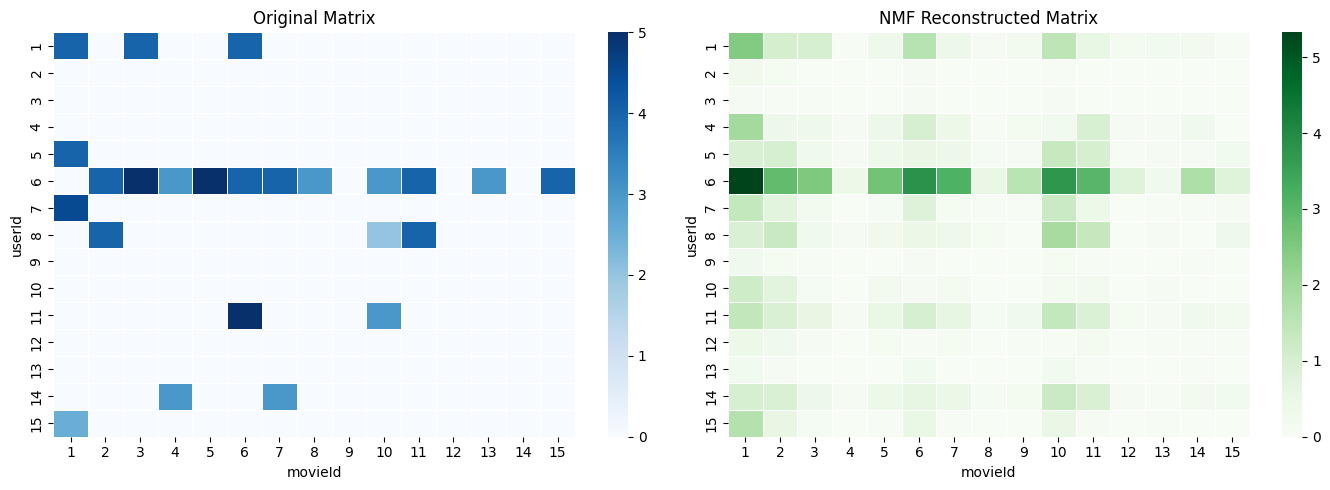

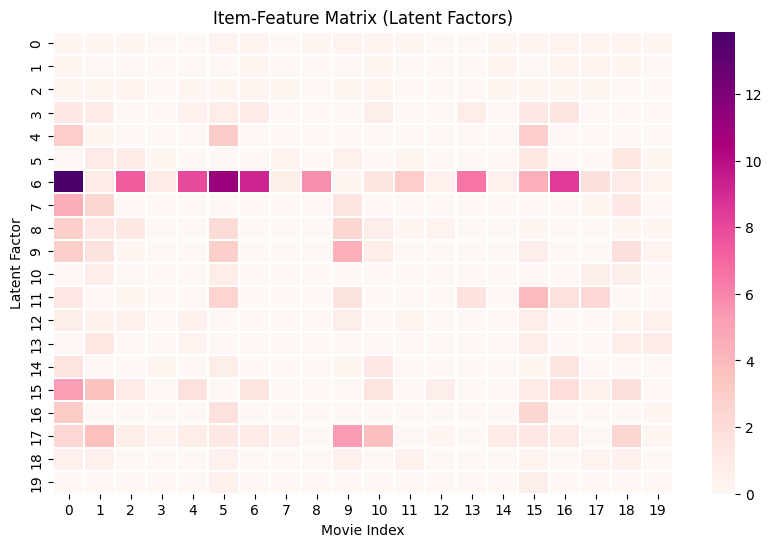

/tmp/ipykernel_5934/2689225297.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_Rating',


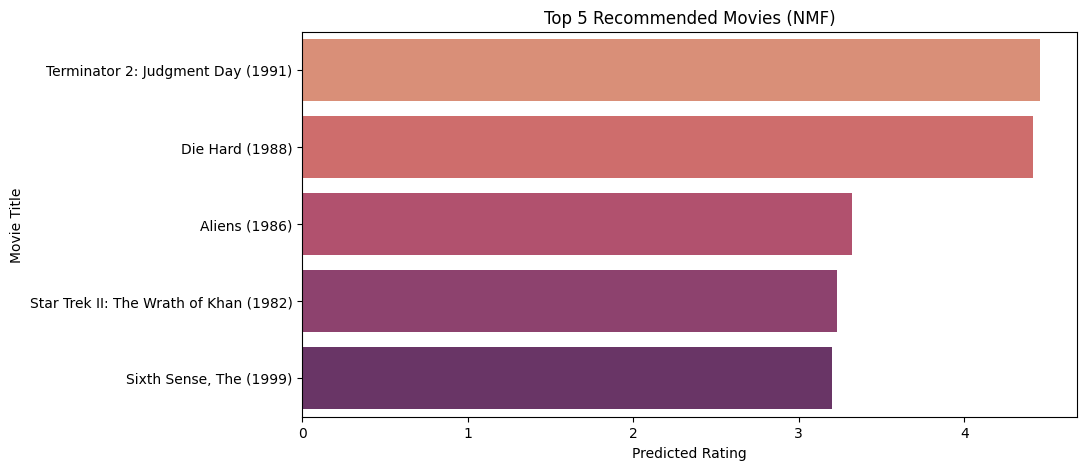

In [5]:
print("Name: Priya Dharshini R")
print("Roll No.: 24BAD092")
print("Scenario 2 – Matrix Factorization using NMF\n")

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# LOAD DATASET
df = pd.read_csv(r"/content/sample_data/ratings.csv")
movies_df = pd.read_csv(r"/content/sample_data/movies.csv")

print(f"Total ratings: {len(df)}")

# CREATE USER-ITEM MATRIX
user_movie_matrix = df.pivot(index='userId', columns='movieId', values='rating')
R = user_movie_matrix.fillna(0).values

print(f"User-Item Matrix Shape: {R.shape}")

# APPLY NMF
k_latent_features = 20

nmf_model = NMF(n_components=k_latent_features,
                init='random',
                random_state=42,
                max_iter=500)

W = nmf_model.fit_transform(R)
H = nmf_model.components_

print(f"Shape of W (User-Features): {W.shape}")
print(f"Shape of H (Item-Features): {H.shape}")

# RECONSTRUCT MATRIX
R_predicted = np.dot(W, H)

preds_df = pd.DataFrame(R_predicted,
                        index=user_movie_matrix.index,
                        columns=user_movie_matrix.columns)

# RECOMMENDATION FUNCTION
def get_nmf_recommendations(preds_df, user_id, original_df, movies_df, top_n=5):

    user_preds = preds_df.loc[user_id].sort_values(ascending=False)
    user_rated = original_df[original_df['userId'] == user_id]['movieId'].tolist()

    unseen_preds = user_preds[~user_preds.index.isin(user_rated)]

    top_movie_ids = unseen_preds.head(top_n).index
    top_scores = unseen_preds.head(top_n).values

    recs = movies_df[movies_df['movieId'].isin(top_movie_ids)].copy()
    recs['Predicted_Rating'] = top_scores

    return recs.sort_values(by='Predicted_Rating', ascending=False)

# GENERATE RECOMMENDATIONS
top_recs = get_nmf_recommendations(preds_df, user_id=1, original_df=df, movies_df=movies_df, top_n=5)

print("\nTop 5 NMF Recommendations for User 1:")
print(top_recs[['title', 'Predicted_Rating']])

# EVALUATION METRICS
mask = user_movie_matrix.values > 0
actual_ratings = user_movie_matrix.values[mask]
predicted_ratings = R_predicted[mask]

rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))
print(f"\nNMF RMSE: {rmse:.4f}")

# Precision & Recall@K
def precision_recall_at_k(predictions, actuals, k=10, threshold=3.5):
    user_precisions = []
    user_recalls = []

    for i in range(len(actuals)):
        top_k_pred_idx = np.argsort(predictions[i])[::-1][:k]
        relevant_actual_idx = np.where(actuals[i] >= threshold)[0]

        if len(relevant_actual_idx) == 0:
            continue

        hits = len(set(top_k_pred_idx).intersection(set(relevant_actual_idx)))

        user_precisions.append(hits / k)
        user_recalls.append(hits / len(relevant_actual_idx))

    return np.mean(user_precisions), np.mean(user_recalls)

p_at_k, r_at_k = precision_recall_at_k(R_predicted, user_movie_matrix.values, k=10)

print(f"Precision@10: {p_at_k:.4f}")
print(f"Recall@10: {r_at_k:.4f}")

# VISUALIZATION (COLORS UPDATED)
# Heatmap Comparison (Dark Shades)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Dark Blue shade
sns.heatmap(user_movie_matrix.iloc[:15, :15].fillna(0),
            cmap='Blues', linewidths=0.5, ax=ax[0])
ax[0].set_title('Original Matrix')

# Dark Green shade
sns.heatmap(preds_df.iloc[:15, :15],
            cmap='Greens', linewidths=0.5, ax=ax[1])
ax[1].set_title('NMF Reconstructed Matrix')

plt.tight_layout()
plt.show()

# Latent Feature Visualization (Pink)
plt.figure(figsize=(10, 6))

#  Pink shade
sns.heatmap(H[:, :20],
            cmap='RdPu',
            linewidths=0.3,
            cbar=True)

plt.title('Item-Feature Matrix (Latent Factors)')
plt.xlabel('Movie Index')
plt.ylabel('Latent Factor')

plt.show()

# Recommendation Bar Chart
plt.figure(figsize=(10, 5))

# Soft matching palette
sns.barplot(x='Predicted_Rating',
            y='title',
            data=top_recs,
            palette='flare')

plt.title('Top 5 Recommended Movies (NMF)')
plt.xlabel('Predicted Rating')
plt.ylabel('Movie Title')

plt.show()